# **Sentiment Analysis**: App Review Classifier
trained on ~49k app reviews (negative, neutral, positive)

Models: Logistic Regression, Naive Bayes, Linear SVC, Random Forest, LSTM.

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import joblib
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

## 1. Load & Preprocess Data

In [19]:
df = pd.read_csv('/content/drive/MyDrive/balanced_dataset_with_sentiment.csv')
df = df.drop(columns=["Review Id", "Review Date", "Ratings"])

df = df.dropna(subset=["Review", "Sentiment"])
df = df.reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(df["Sentiment"].value_counts())

Dataset shape: (49612, 2)
Sentiment
Positive    26000
Negative    15455
Neutral      8157
Name: count, dtype: int64


## 2. Train/Test Split & Class Weights

In [20]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df["Review"] = df["Review"].apply(clean_text)

mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["Sentiment"] = df["Sentiment"].map(mapping)

X_text = df["Review"]
y = df["Sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

results = []

In [21]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
weights_dict = dict(enumerate(class_weights))
print(weights_dict)

{0: np.float64(1.0700150975951688), 1: np.float64(2.0275351213282247), 2: np.float64(0.6360416666666666)}


## 3. TF-IDF Models

In [22]:
#fit vectorizer on TRAINING data only to prevent data leakage
vectorizer = TfidfVectorizer(stop_words="english", max_features=20000)
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [23]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_test, lr_pred, target_names=["Negative", "Neutral", "Positive"]))

lr_accuracy = accuracy_score(y_test, lr_pred)
results.append(["Logistic Regression", lr_accuracy])
joblib.dump(lr_model, "logistic_regression_model.pkl")

Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.63      0.65      0.64      3091
     Neutral       0.25      0.45      0.32      1632
    Positive       0.79      0.58      0.67      5200

    accuracy                           0.58      9923
   macro avg       0.56      0.56      0.54      9923
weighted avg       0.65      0.58      0.60      9923



['logistic_regression_model.pkl']

In [24]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print("Naive Bayes:")
print(classification_report(y_test, nb_pred, target_names=["Negative", "Neutral", "Positive"]))

nb_accuracy = accuracy_score(y_test, nb_pred)
results.append(["Naive Bayes", nb_accuracy])
joblib.dump(nb_model, "naive_bayes_model.pkl")

Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.70      0.62      0.66      3091
     Neutral       0.40      0.01      0.01      1632
    Positive       0.68      0.93      0.78      5200

    accuracy                           0.68      9923
   macro avg       0.59      0.52      0.49      9923
weighted avg       0.64      0.68      0.62      9923



['naive_bayes_model.pkl']

In [25]:
svm_model = LinearSVC(max_iter=2000, class_weight='balanced')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("Linear SVC:")
print(classification_report(y_test, svm_pred, target_names=["Negative", "Neutral", "Positive"]))

svc_accuracy = accuracy_score(y_test, svm_pred)
results.append(["Support Vector Machine", svc_accuracy])
joblib.dump(svm_model, "svm_model.pkl")

Linear SVC:
              precision    recall  f1-score   support

    Negative       0.69      0.61      0.65      3091
     Neutral       0.29      0.20      0.23      1632
    Positive       0.71      0.84      0.77      5200

    accuracy                           0.66      9923
   macro avg       0.56      0.55      0.55      9923
weighted avg       0.64      0.66      0.64      9923



['svm_model.pkl']

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, rf_pred, target_names=["Negative", "Neutral", "Positive"]))

rf_accuracy = accuracy_score(y_test, rf_pred)
results.append(["Random Forest", rf_accuracy])
joblib.dump(rf_model, "random_forest_model.pkl")

Random Forest:
              precision    recall  f1-score   support

    Negative       0.68      0.65      0.66      3091
     Neutral       0.23      0.19      0.21      1632
    Positive       0.71      0.77      0.74      5200

    accuracy                           0.64      9923
   macro avg       0.54      0.54      0.54      9923
weighted avg       0.62      0.64      0.63      9923



['random_forest_model.pkl']

## 4. LSTM

In [27]:
# LSTM — reuse the same train/test text split (no separate split)
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)
max_len = 100
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test_text),  maxlen=max_len, padding="post")

joblib.dump(tokenizer, "lstm_tokenizer.pkl")

['lstm_tokenizer.pkl']

In [29]:
model = Sequential([
    Embedding(vocab_size, 128),
    LSTM(64),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop],
    class_weight=weights_dict
)

loss, accuracy = model.evaluate(X_test_pad, y_test)
print("LSTM Test Accuracy:", accuracy)
results.append(["LSTM", accuracy])
model.save("lstm_model.keras")

Epoch 1/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3379 - loss: 1.0995 - val_accuracy: 0.1648 - val_loss: 1.1036
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3168 - loss: 1.0993 - val_accuracy: 0.5270 - val_loss: 1.0960
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3242 - loss: 1.0988 - val_accuracy: 0.5243 - val_loss: 1.0798
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3624 - loss: 1.0998 - val_accuracy: 0.1651 - val_loss: 1.1032
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3741 - loss: 1.0979 - val_accuracy: 0.3115 - val_loss: 1.0867
311/311 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5243 - loss: 1.0798
LSTM Test Accuracy: 0.5243374109268188


## 5. Results & Evaluation

In [30]:
comparison = pd.DataFrame(results, columns=["Model", "Accuracy"])
comparison = comparison.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nModel Comparison:")
print(comparison.to_string(index=False))


Model Comparison:
                 Model  Accuracy
           Naive Bayes  0.683362
Support Vector Machine  0.659377
         Random Forest  0.637912
   Logistic Regression  0.581477
                  LSTM  0.524337


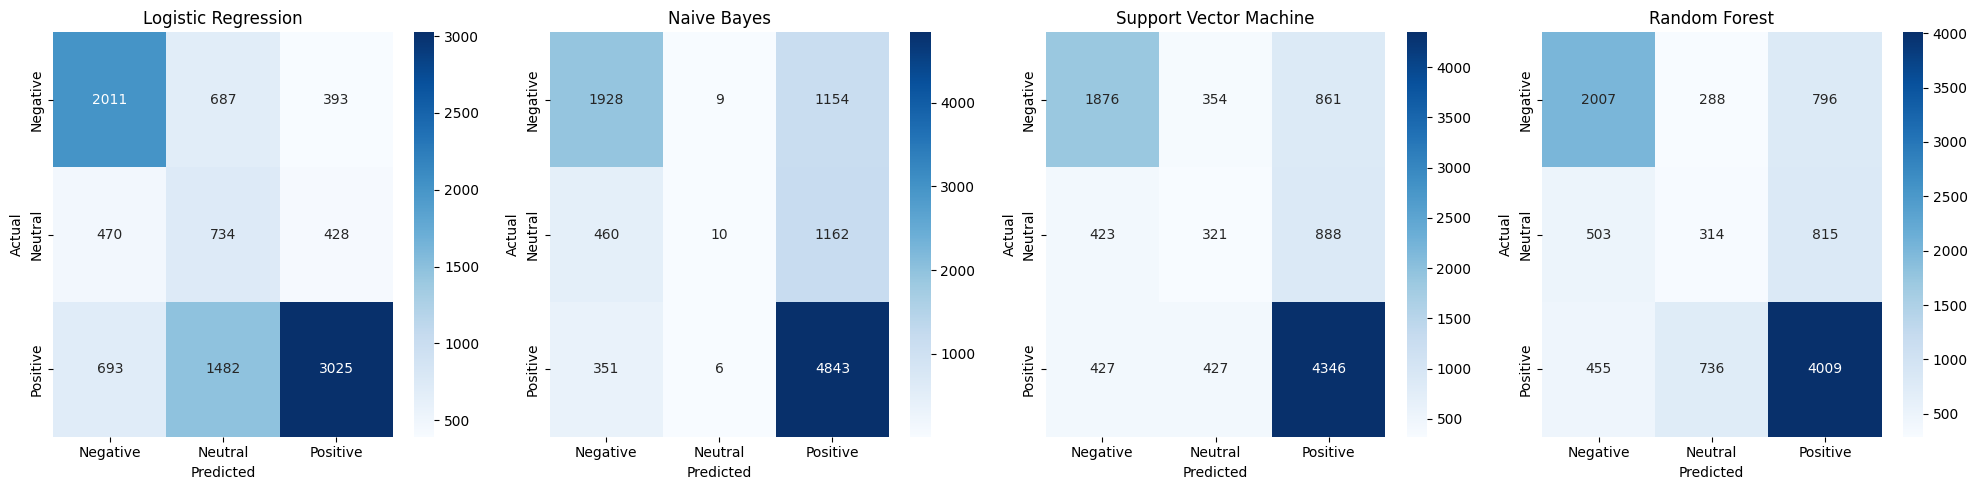

In [31]:
#confusion matrix
labels = ["Negative", "Neutral", "Positive"]
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Support Vector Machine": svm_pred,
    "Random Forest": rf_pred,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


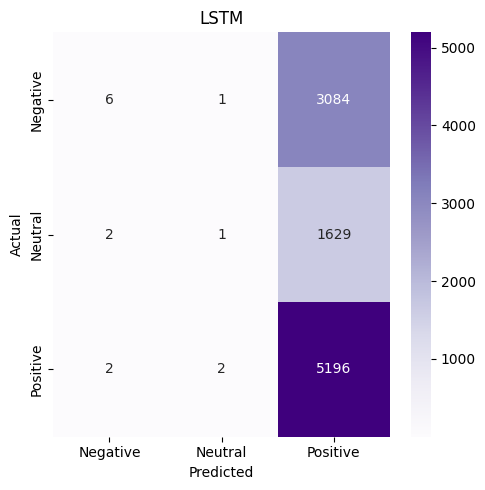

In [32]:
#confusion matrix for LSTM
lstm_preds = np.argmax(model.predict(X_test_pad), axis=1)

fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, lstm_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)
ax.set_title("LSTM")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = lr_model.predict(vec)[0]
    return {0: "Negative", 1: "Neutral", 2: "Positive"}[pred]

predict_sentiment("great app")

'Positive'